# Figure 3 — Mobility behavior and residential segregation

The two commented reference cells document the upstream model calculations. Run the final two Python cells to reproduce the figure from the plotting tables in `data/`. 

## Derivation of the plotting tables (reference only)

These cells are fully commented because the user-level input is deliberately excluded from this folder. Panel a uses unstandardized model predictions; panel b uses within-city standardized interaction coefficients.


In [ ]:
# Panel a: 
# Reference only: these upstream inputs are not included in code_paper.
# R code, shown to document how fig3a_predictions.csv was produced:
# users <- read.csv("users_merged_loo_log.csv", colClasses = c(GEOID_home = "character"))
# users$cty_GEOID <- substr(users$GEOID_home, 1, 5)
# users$tract_GEOID <- substr(users$GEOID_home, 1, 11)
# users$avg_disthome_weighted <- log(users$avg_disthome_weighted / 1000)
# global_y_min <- min(users$avg_disthome_weighted, na.rm = TRUE)
# global_y_max <- max(users$avg_disthome_weighted, na.rm = TRUE)
# city_data <- subset(users, msa == city)
# raw_model <- lmer(
#   S_exp ~ S_res * sigma_s + S_res * avg_disthome_weighted +
#     perc_grad + perc_black + perc_hisp + income_log + ratio_poverty + perc_labor +
#     (1 | cty_GEOID / tract_GEOID),
#   data = city_data, weights = weight_norm_msa,
#   control = lmerControl(optimizer = "bobyqa")
# )
# grid <- expand.grid(
#   S_res = seq(-1, 1, length.out = 100),
#   avg_disthome_weighted = seq(global_y_min, global_y_max, length.out = 100)
# )
# Other numeric predictors were set to their city means; grouping variables
# were assigned their city's most frequent value, as in the original script.
# grid$pred <- predict(raw_model, newdata = grid, re.form = NA)
# Repeat for each of the 11 cities, then save city, S_res, log distance, pred.


In [2]:
# Panel b: within-city standardized interaction coefficients
# Reference only: these upstream inputs are not included in code_paper.
# R code, shown to document how fig3b_interactions.csv was produced:
# users_scaled <- users %>% group_by(msa) %>% mutate(
#   S_res_sc = scale(S_res),
#   sigma_s_sc = scale(sigma_s),
#   avg_disthome_weighted_sc = scale(avg_disthome_weighted),
#   perc_grad_sc = scale(perc_grad), perc_black_sc = scale(perc_black),
#   perc_hisp_sc = scale(perc_hisp), income_log_sc = scale(income_log),
#   ratio_poverty_sc = scale(ratio_poverty), perc_labor_sc = scale(perc_labor)
# ) %>% ungroup()
# city_scaled <- subset(users_scaled, msa == city)
# scaled_model <- lmer(
#   S_exp ~ S_res_sc * sigma_s_sc +
#     S_res_sc * avg_disthome_weighted_sc +
#     perc_grad_sc + perc_black_sc + perc_hisp_sc +
#     income_log_sc + ratio_poverty_sc + perc_labor_sc +
#     (1 | cty_GEOID / tract_GEOID),
#   data = city_scaled, weights = weight_norm_msa,
#   control = lmerControl(optimizer = "bobyqa")
# )
# coefs <- summary(scaled_model)$coefficients
# Save Estimate and Std. Error for the two S_res_sc interaction terms per city.
# The plotted 95% intervals are estimate +/- 1.96 * standard_error.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch

# Run from code_paper/ or from the repository root.
data_dir = Path("data") if Path("data/fig3a_predictions.csv").is_file() else Path("code_paper/data")
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 28,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "pdf.fonttype": 42,
})

predictions = pd.read_csv(data_dir / "fig3a_predictions.csv")
interactions = pd.read_csv(data_dir / "fig3b_interactions.csv")
city_order = sorted(predictions["city"].unique())
assert len(city_order) == 11
assert predictions.groupby("city").size().eq(10_000).all()
assert interactions.groupby("city").size().eq(2).all()


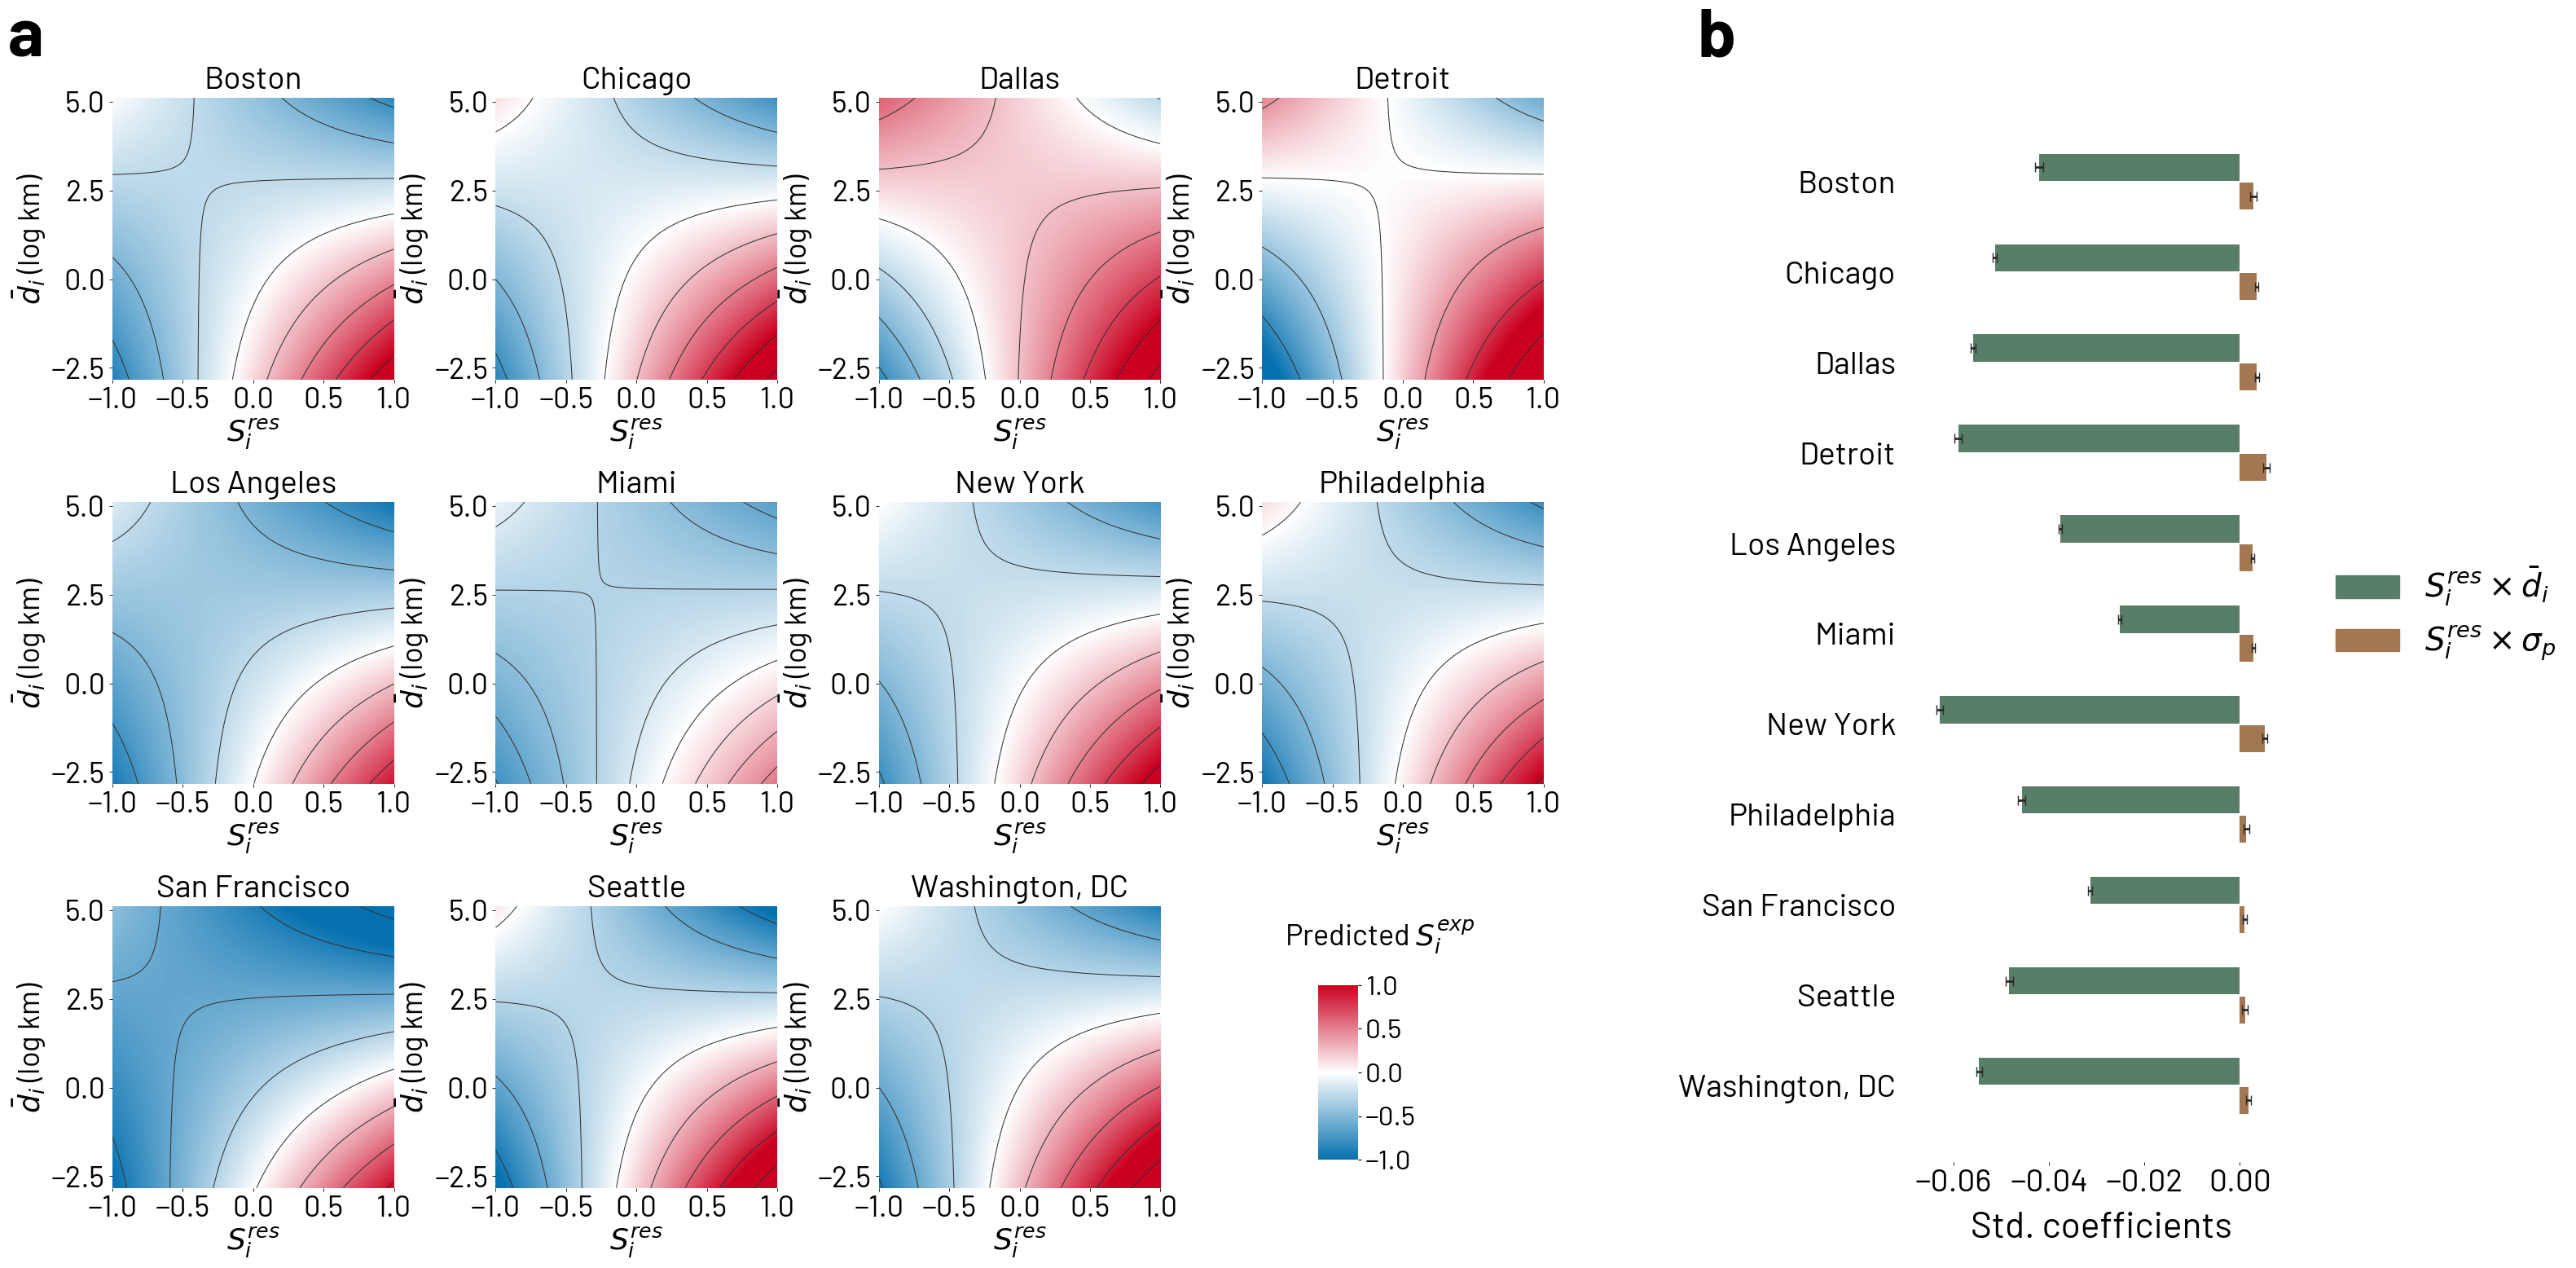

In [4]:
# Panel a keeps the original prediction scale; panel b uses the published
# standardized coefficients and their 95% intervals (estimate +/- 1.96 SE).
# Apply the bundled font immediately before drawing the figure.
from matplotlib import font_manager
font_dirs = ['font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams['font.family'] = 'Barlow'

fig = plt.figure(figsize=(32, 16), facecolor="white")
# Fixed square panels leave room for every axis label, a clear gap before
# panel b, and a separate legend to its right.
panel_width = 0.108
panel_height = panel_width * fig.get_figwidth() / fig.get_figheight()
column_left = [0.052, 0.199, 0.346, 0.493]
row_bottom = [0.70, 0.39, 0.08]
segregation_cmap = LinearSegmentedColormap.from_list(
    "segregation", ["#0571b0", "#ffffff", "#ca0020"]
)
color_scale = Normalize(vmin=-1, vmax=1)

for i, city in enumerate(city_order):
    row, col = divmod(i, 4)
    ax = fig.add_axes([column_left[col], row_bottom[row], panel_width, panel_height])
    city_grid = predictions.loc[predictions["city"] == city].sort_values(
        ["log_mean_distance_km", "S_res"]
    )
    x = np.sort(city_grid["S_res"].unique())
    y = np.sort(city_grid["log_mean_distance_km"].unique())
    z = city_grid["predicted_S_exp"].to_numpy().reshape(len(y), len(x))
    raster = ax.imshow(
        z, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto", interpolation="bilinear", cmap=segregation_cmap,
        norm=color_scale,
    )
    ax.contour(x, y, z, levels=8, colors="#333333", linewidths=0.75, linestyles="solid")
    ax.set_xlim(-1, 1)
    ax.set_ylim(y.min(), y.max())
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks([-2.5, 0, 2.5, 5])
    ax.set_title(city, pad=8)
    ax.tick_params(axis="both", length=3, width=0.6)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$S_i^{res}$", labelpad=3)
    ax.set_ylabel(r"$\bar{d}_i$ (log km)", labelpad=3)
    for spine in ax.spines.values():
        spine.set_visible(False)

# The twelfth grid cell holds a compact key, beside the final contour plot.
key_ax = fig.add_axes([column_left[3], row_bottom[2], panel_width, panel_height])
key_ax.axis("off")
key_ax.text(0.08, 0.96, r"Predicted $S_i^{exp}$", fontsize=26,
            ha="left", va="top", transform=key_ax.transAxes)
cax = key_ax.inset_axes([0.20, 0.10, 0.14, 0.62])
cbar = fig.colorbar(raster, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=24, length=3)

ax_b = fig.add_axes([0.74, 0.10, 0.15, 0.81])
# Requested palette for the two standardized interaction terms.
term_colors = {
    "S_res_sc:avg_disthome_weighted_sc": "#587E68",
    "S_res_sc:sigma_s_sc": "#A27752",
}
term_labels = {
    "S_res_sc:avg_disthome_weighted_sc": r"$S_i^{res} \times \bar{d}_i$",
    "S_res_sc:sigma_s_sc": r"$S_i^{res} \times \sigma_p$",
}
for term, offset in [
    ("S_res_sc:avg_disthome_weighted_sc", -0.16),
    ("S_res_sc:sigma_s_sc", 0.16),
]:
    values = interactions.loc[interactions["term"] == term].set_index("city").loc[city_order]
    positions = np.arange(len(city_order)) + offset
    ax_b.barh(positions, values["estimate"], height=0.30,
              color=term_colors[term])
    ax_b.errorbar(values["estimate"], positions,
                  xerr=1.96 * values["standard_error"],
                  fmt="none", ecolor="#292929", elinewidth=2.0, capsize=4)
ax_b.set_yticks(np.arange(len(city_order)), city_order)
ax_b.invert_yaxis()
ax_b.set_xlim(-0.07, 0.012)
ax_b.set_xticks([-0.06, -0.04, -0.02, 0])
ax_b.set_xlabel("Std. coefficients", labelpad=12, fontsize=32)
ax_b.tick_params(axis="x", length=3, width=0.6, labelsize=28)
ax_b.tick_params(axis="y", length=0, pad=9, labelsize=28)
fig.legend(
    handles=[Patch(color=term_colors[t], label=term_labels[t]) for t in term_colors],
    frameon=False, fontsize=28, loc="center left", bbox_to_anchor=(0.90, 0.52),
    ncol=1, borderaxespad=0,
)
for spine in ax_b.spines.values():
    spine.set_visible(False)

fig.text(0.012, 0.985, "a", fontsize=60, fontweight="bold", va="top")
fig.text(0.66, 0.985, "b", fontsize=60, fontweight="bold", va="top")
fig.savefig("fig_3.pdf", bbox_inches="tight")
plt.show()
